## Eigenvalues and Eigenvectors

With the linearized system matrices available, we have a powerful representation for analyzing the response of an aircraft. However, the primary methodology we'll use to make these evaluations -- eigenvalue and eigenvector analysis -- is a complex topic in its own right that requires its own upfront explanation. This section covers the development of the first-order "standard" eigenvalue problem, discusses basic characteristics of first- and second-order systems, and provides examples of the visualization tools used to understand and analyze fundamental dynamic system characteristics. 

### Eigen-Decomposition of Linear Dynamic Systems

To set up the eigenvalue problem we'll trim down the state-space system to just its "homogenous" state equation, free of any other inputs. (I'll dispense with the $\Delta$ notation from the "linearization" section for the time being, since it's ugly)

$$
\dot{\mathbf{x}} = \mathbf{A}\mathbf{x}
$$

This equation has a general solution of the form $\mathbf{x}(t) = \mathbf{e}^{\mathbf{A} t} \mathbf{x}_0$ for initial conditions $\mathbf{x}_0$. The matrix exponential can be nasty to compute, but still has the property that $\dfrac{d}{dt}\mathbf{e}^{\mathbf{A} t} =  \mathbf{A}\mathbf{e}^{\mathbf{A} t}$; thus for our assumed form $\dfrac{d}{dt} e^{\mathbf{A} t}\mathbf{x}_0  =  \mathbf{A}\mathbf{e}^{\mathbf{A} t} \mathbf{x}_0 = \mathbf{A}\mathbf{x}(t)$ which satisfies the original differential equation.

If we could get the matrix exponential into a form that had only diagonal entries in its exponent, it simplifies down to a "diagonalized" version of the standard scalar exponential function. This would mean finding a matrix $\mathbf{P}$ such that $\mathbf{PAP^{-1}} = \mathbf{D}$ with a diagonal matrix $\mathbf{D}$. Unfortunately, the full 6x6 matrices we developed previously are **not** diagonalizable, which means we can't take this approach directly. Instead, we'll make another "assumption" (which we know to be true) that it is possible to end up with a proper diagonalization into a matrix $\mathbf{\Lambda}$ via a transformation matrix $\mathbf{\Phi}$ such that

$$
\mathbf{x}(t) = \mathbf{e}^{\mathbf{\Lambda}t}\mathbf{\Phi}\mathbf{q}_0 = \sum_i \boldsymbol{\phi}_i e^{\lambda_i t}(q_0)_i
$$

Where $\boldsymbol{\phi}_i$, $\lambda_i$, and $(q_0)_i$ corresponds to the $i^{th}$ column of $\mathbf{\Phi}$, diagonal entry of $\mathbf{\Lambda}$, and coefficient in the vector $\mathbf{q}_0$. If we assume that all but the $i^{th}$ entry is zero (for an arbitrary index) the summation drops from the right-most expression. Substituting this into the differential equation results in

$$
\lambda_i{\boldsymbol{\phi}_i}e^{\lambda_i t}(q_0)_i =
\mathbf{A}{\boldsymbol{\phi}_i}e^{\lambda_i t}(q_0)_i
$$

Dividing through by the scalar term $e^{\lambda_i t}\cdot (q_0)_i$ leads to a form of the **standard eigenvalue problem**: 
$$
\lambda_i{\boldsymbol{\phi}_i} =
\mathbf{A}{\boldsymbol{\phi}_i} $$

This development is a bit frustrating in that to reveal the eigenvalue problem we first had to assume the concept of an "eigenvalue" and "eigenvector" existed, so it seems to be missing a more fundamental first principle. We'll keep going though instead of getting hung up on a minor shortfall. (Etkin & Reid, for example, use an identical development with slightly different nomenclature in Eqs. (6.1,3 - 6.1,6)).

Since eigenvalues/vectors occur in so many technical contexts, it can be difficult to keep track of the physical interpretation for a given application. For this situation, there is a particularly elegant connection due to the simplicity of the differential equation. If we assume an arbitrary $x = q_i\boldsymbol{\phi}_i$ that is proportional to an eigenvector, the state vector rate of change is:

$$
\dot{\mathbf{x}} = \mathbf{A} q_i\boldsymbol{\phi}_i = q_i \lambda_i{\boldsymbol{\phi}_i}
$$

This means that the **derivative of the state vector occurs in the same orientation as the current state vector**, up to a scaling by the associated eigenvalue. This means motion that initiates in a single eigenvector stays in the same direction as that eigenvector (with a catch that we'll discuss shortly) or put another way, that each eigenvector is "decoupled" from the rest. We can refer to these distinct eigenvectors as "modes of motion" and the shapes of each eigenvector as a "modeshape." Note that even in the general case where motion is occuring in multiple modes, this decoupling property still holds, since each mode involved in the overall summation can be calculated independently. This is the fundamental property of eigenvectors that makes them such a powerful tool, and is something we'll examine in detail in this section. First, though, we must work through some concepts associated with the eigenvalues.



### Properties of Eigenvalues


Although the orientation of the state vector derivative is the same as each modeshape, the eigenvalue scaling still has a significant impact. Along with the introduction of "modeshape" in place of "eigenvector" above, I'll note that controls engineers often refer to eigenvalues as "poles," while in structural dynamics they are referred to as "natural frequencies." The former term is more general than the latter, and "natural frequency" will be an evaluation metric we define further below.

#### Real Eigenvalues/First Order Response
In the simplest case where an eigenvalue is real with $\lambda_i = n$, the equation of motion for $q_i(t)$ simplifies to

$$
\dot{\mathbf{x}} = {\boldsymbol{\phi}_i}\dot{q}_i = q_i \lambda_i{\boldsymbol{\phi}_i} \Rightarrow \dot{q}_i = q_i \lambda_i
$$

The resulting right-hand expression is simply a first-order differential equation which decays according to the magnitude of the real eigenvalue $n$. The motion is unstable if $n > 0$; an instability associaed with a real-valued eigenvalue is said to be "statically unstable." An $n$ with large magnitude will grow or decay more quickly. The typical way to characterize the timescale of this first-order response is by defining the **time to double/half** as the time it takes to double (for an unstable system) or cut in half (for a stable system) the initial value. For a starting $q_0$ this is found from:

$$
2 q_0 = q_0 e^{nt_2}
$$
$$
\Rightarrow t_2 = \log(2)/n \approx 0.693/n
$$

It is worth noting at this point that the unit of an eigenvector is the rad/s so that the units above (and in the matrix exponential) work out. The other measure of the first-order response is the "bandwidth" which is simply $n$. Demonstration of this requires a foray into frequency domain transfer functions, which I will hold off on until we get to controlled response of the aircraft.

An illustration of stable and unstable responses with respect to nondimesional $t/n$ and is plotted below:




Text(0.5, 1.0, 'Demonstration of First-Order Response $\\mathbf{q(t) = q_0\\cdot e^{n\\cdot t}}$ for Stable and Unstable $\\mathbf{n}$')

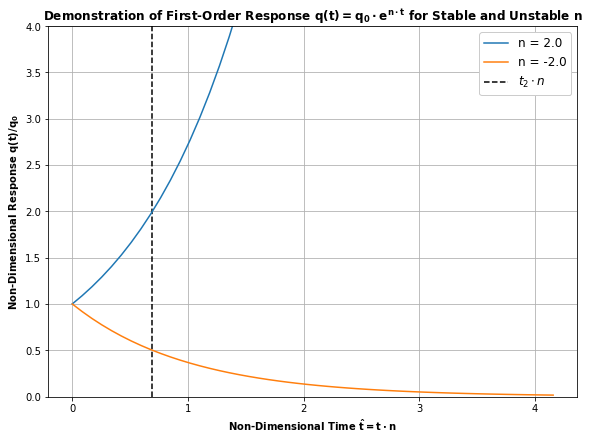

In [2]:

n_vec = [2.0, -2.0]

fig, ax = plt.subplots(1, 1, figsize = (8, 6), constrained_layout = True)
tvec = np.linspace(0., 6*np.log(2)/n_vec[0])
q0 = 1.5

for n in n_vec:
    
    q = q0*np.exp(n*tvec)
    
    ax.plot(tvec*n_vec[0], q/q0, label = 'n = %.1f' % n)
    
yl = [0., 4.]
ax.vlines(np.log(2), *yl, 'k', linestyle = '--', label = '$t_{2}\cdot n$')
ax.set_ylim(yl)
ax.grid()

ax.legend(framealpha = 1., fontsize = 12)
ax.set_xlabel('Non-Dimensional Time $\mathbf{\hat{t} = t\cdot n}$', fontweight = 'bold')
ax.set_ylabel('Non-Dimensional Response $\mathbf{q(t)/q_0}$', fontweight = 'bold')
ax.set_title('Demonstration of First-Order Response $\mathbf{q(t) = q_0\cdot e^{n\cdot t}}$ for Stable and Unstable $\mathbf{n}$', 
            fontweight = 'bold')

The final note about the first-order case is that, since the eigenvalue is real, all entries in the eigenvector must be real as well. This keeps the overall situation quite simple compared to the oscillatory case, which is up next for discussion.

#### Complex Eigenvalues/Second Order Response
It is also possible for eigenvalues to be complex-valued. These correspond to oscillatory responses which are "secon-order" in nature; that is, the require both a "displacemement" and a "velocity" state in the equation of motion. Etkin and Reid demonstrate how the second-order response arises given a known form of the eigenvalue, but I'll go backwards. If we assume the response is second-order, its differential equation has the form

$$
\ddot{z} + 2\zeta\omega_n \dot{z} + \omega_n^2 z = 0
$$

for a new variable $z$. Since we're dealing with eigenvalues of first-order systems we can convert the above to first-order form using by introducing new variables $y_1 = z$ and $y_2 = \dot{z}$. The equivalent matrix equation is then

$$
\begin{Bmatrix}
\dot{y_1} \\ \dot{y_2}
\end{Bmatrix}
=
\begin{bmatrix}
0 & 1 \\
-\omega_n^2 & -2\zeta\omega_n 
\end{bmatrix}
\begin{Bmatrix}
y_1 \\ y_2
\end{Bmatrix}
$$

The eigenvalues of this system are obtained by finding the 2x2 determinant of:

$$
\begin{bmatrix}
0 & 1 \\
-\omega_n^2 & -2\zeta\omega_n 
\end{bmatrix} - \lambda \mathbf{I}_{2,2} = \begin{bmatrix}
-\lambda & 1 \\
-\omega_n^2 & -(\lambda + 2\zeta\omega_n) 
\end{bmatrix}
$$

which results in the characteristic equation:

$$
\lambda\cdot(\lambda + 2\zeta\omega_n) + \omega_n^2 = \lambda^2 + 2\zeta\omega_n \lambda + \omega_n^2
$$

This has a pair of solutions for the eigenvalue:

$$
\lambda_{1,2} = -\zeta\omega_n \pm \sqrt{4\zeta^2\omega_n^2 - 4\omega_n^2}/2
$$

Since $\zeta < 1$ for an oscillatory response the term inside the radical must be negative and result in a complex argument:

$$
\lambda_{1,2} = -\zeta\omega_n \pm j\omega_n \sqrt{1 - \zeta^2}
$$

The term $\omega_n\sqrt{1 - \zeta^2}$ is the **damped natural frequency** and will be denoted as simply $\omega$. We can call the real part $n = -\zeta\omega_n$ to result in the commonly published form $\lambda_{1,2} = n \pm j\omega$ for the oscillatory eigenvalues. This means:

- The eigenvalues are **complex conjugates** of each other
- To get the **natural frequency** from the eigenvalues' real and imaginary parts we have $\omega_n = \sqrt{\omega^2 + n^2} = |\lambda|$
- To get the **damping ratio** from the eigenvalues' real and imaginary parts we have $\zeta = -n/\omega_n = -\Re(\lambda)/|\lambda|$. As with the first order system, a positive $n$ (and negative damping ratio) indicates an unstable system -- in this case we refer to it as "dynamically unstable" when the real term is positive and $\omega$ is nonzero. 

But what about the eigenvectors? Since the eigenvalues are complex-valued, the eigenvectors must also be complex-valued in order to arrive at real-valued time derivatives. These are found by solving for the null space of the eigenvalue matrix:

$$
\begin{bmatrix}
-\lambda & 1 \\
-\omega_n^2 & -(\lambda + 2\zeta\omega_n) 
\end{bmatrix}
\begin{Bmatrix}
\phi_1 \\
\phi_2
\end{Bmatrix}
=
\begin{Bmatrix}
0 \\
0
\end{Bmatrix}
$$

Leading to 

$$
\phi_2 = \lambda_1 \phi_1 
$$
$$
\phi_1\omega_n^2  + \phi_2 (\lambda + 2\zeta\omega_n^2) = 0
$$
$$
\Rightarrow \phi_1\omega_n^2 + \lambda\phi_1 (\lambda + 2\zeta\omega_n^2) = 0
$$
$$
\Rightarrow \phi_1(\lambda^2 + 2\zeta\omega_n \lambda + \omega_n^2) = 0
$$

So the value of $\phi_1$ must be nonzero but is otherwise arbitrary in this formulation. The final step would be to scale the eigenvector, but for the first-order system/standard eigenvalue formulation, this is not critical -- the equality $\mathbf{A}\boldsymbol{\phi} = \lambda \boldsymbol{\phi}$ is met for any scalar multiple of $\phi$. Things change when solving the "generalized" eigenvalue problem, but that's a different discussion. 

All that said, the eigenvectors we will use going forward are:

$$
\phi_{1,2} = \begin{Bmatrix} 1 \\ \lambda_{1, 2} \end{Bmatrix} = \begin{Bmatrix} 1 \\ n \pm j\omega \end{Bmatrix}
$$




This leaves us in a position to demonstrate the 2nd order system response in terms of the eigenvalues and corresponding physical coordinates. To set up the initial condition I'll select one of the eigenvectors and use its coordinates as the system initial conditions, so that:

$$
\begin{Bmatrix}
y_1 \\ y_2
\end{Bmatrix}_0
=
\begin{Bmatrix}
1 \\ 
n + j\omega
\end{Bmatrix}
$$

Small problem: The initial condition has a complex component to it. Since the complex entry has a complex conjugate in its other eigenvalue, we can get a purely real response by using both modal coordinates $q_1$ and $q_2$:

$$
\begin{Bmatrix}
y_1 \\ y_2
\end{Bmatrix}_0
=
q_1 
\begin{Bmatrix}
1 \\ 
n + j\omega
\end{Bmatrix}
+ 
q_2 
\begin{Bmatrix}
1 \\ 
n - j\omega
\end{Bmatrix}
$$

So, for $q_1 = q_2$ = 0.5, $y_1 = 1$ and $y_2$ = n. The block below simulates the response for several values of $\zeta$, including a lightly unstable response. Two simulations are performed and plotted:
- First, the physical coordinates $\mathbf{y}$ are simulated and used to obtain the modal coordinates via $\mathbf{q = \Phi^{-1}y}$. The simulation is performed by creating a [scipyl.signal.lti](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lti.html) instance of the state-space system and using [scipy.signal.lsim](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lsim.html). These results are plotted with **solid lines**.
- Then the modal coordinates $\mathbf{q}$ are simulated and used to obtain physical coordinates via $\mathbf{y = \Phi q}$. The result is obtained via analytically evaluating $q_i(t) = (q_i)_0 e^{\lambda_i t}$ for each eigenvalue. These results are plotted with **dashed lines**. 

In all cases, a modal condition $q_1 = q_2 = 0.5$ is used, as shown above. 

Exception for zeta = 1.00: Singular matrix


Text(0.5, 0.98, '2nd Order System Responses for Various Damping Ratios\nSolid Lines Simulated in Physical Coordinates;Dashed Lines in Modal Coordinates')

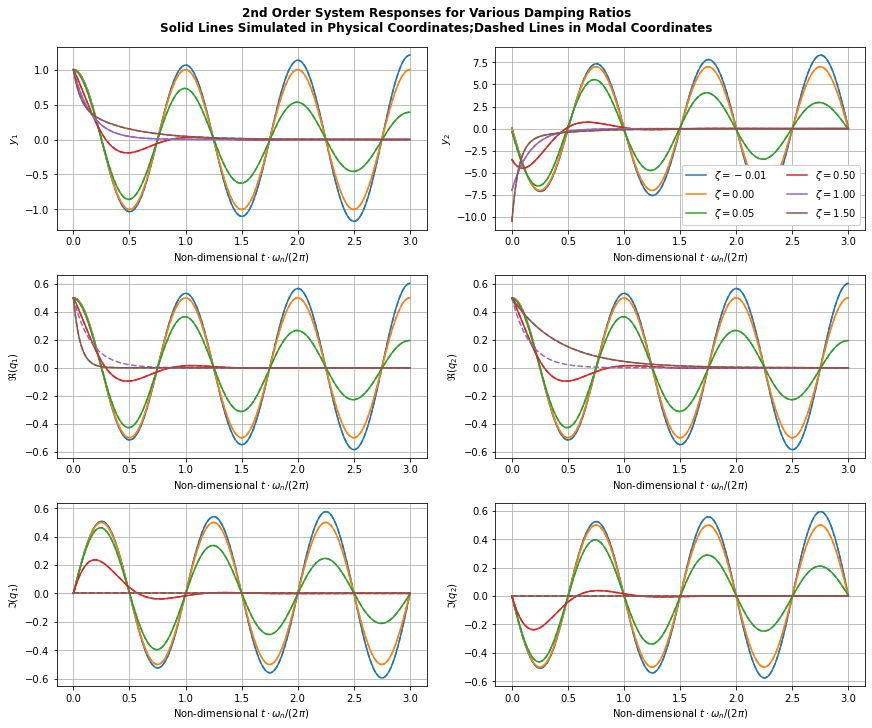

In [76]:

# Simulation of 2nd order response in physical and modal coordinates
from scipy.signal import lti, lsim

omega_n = 7.0
t = np.linspace(0., 3.*2*np.pi/omega_n, 1000)
fig, ax_dict = plt.subplot_mosaic([['$y_1$', '$y_2$'], 
                                  ['$\Re(q_1)$', '$\Re(q_2)$'],
                                  ['$\Im(q_1)$', '$\Im(q_2)$']], figsize = (12, 10), 
                                 constrained_layout = True)

q1 = 0.5
q2 = 0.5
u = 0*t
for zeta in [-0.01, 0.0, 0.05, 0.5, 1.00, 1.5]:
    
    A = np.array([[0., 1.], [-omega_n**2, -2*zeta*omega_n]])
    B = np.zeros((2, 1))
    C = np.eye(2)
    D = np.zeros((2, 1))
    
    sys_phys = lti(A, B, C, D)
    
    lambda_1 = -zeta*omega_n + 1j*omega_n*np.sqrt(np.complex128((1 - zeta**2)))
    lambda_2 = -zeta*omega_n - 1j*omega_n*np.sqrt(np.complex128((1 - zeta**2)))
    
    phi_1 = np.array([[1, ], [lambda_1]])
    phi_2 = np.array([[1, ], [lambda_2]])
    Phi = np.hstack([phi_1, phi_2])
    
    X0 = q1*phi_1 + q2*phi_2

    # Physical system
    _, y_phys, _ = lsim(sys_phys, u, t, X0 = np.real(X0.flatten()))
    
    t_hat = t*omega_n/(2*np.pi)
    g, = ax_dict['$y_1$'].plot(t_hat, y_phys.T[0], label = '$\zeta = %.2f$' % zeta)
    ax_dict['$y_2$'].plot(t_hat, y_phys.T[1], label = '$\zeta = %.2f$' % zeta)
    
    # Eigenvalue-based system
    q1_eig = q1*np.exp(lambda_1*t)
    q2_eig = q2*np.exp(lambda_2*t)
    Q = np.vstack([[q1_eig], [q2_eig]])
    y_eig = np.real(Phi @ Q)  # To avoid the plotting "cast" warnings
    
    ax_dict['$y_1$'].plot(t_hat, y_eig[0], '--', color = g.get_color())
    ax_dict['$y_2$'].plot(t_hat, y_eig[1], '--', color = g.get_color())
    
    ax_dict['$\Re(q_1)$'].plot(t_hat, np.real(q1_eig), '--', color = g.get_color())
    ax_dict['$\Re(q_2)$'].plot(t_hat, np.real(q2_eig), '--', color = g.get_color())
    
    ax_dict['$\Im(q_1)$'].plot(t_hat, np.imag(q1_eig), '--', color = g.get_color())
    ax_dict['$\Im(q_2)$'].plot(t_hat, np.imag(q2_eig), '--', color = g.get_color())
    
    # For zeta = 1 we can't invert the physical coordinates to obtain modal coordinates
    try:
        q_phys = np.linalg.inv(Phi) @ y_phys.T
    except Exception as e:
        print('Exception for zeta = %.2f: %s' % (zeta, e))
        continue
    
    ax_dict['$\Re(q_1)$'].plot(t_hat, np.real(q_phys[0]), color = g.get_color())
    ax_dict['$\Re(q_2)$'].plot(t_hat, np.real(q_phys[1]), color = g.get_color())
    
    ax_dict['$\Im(q_1)$'].plot(t_hat, np.imag(q_phys[0]), color = g.get_color())
    ax_dict['$\Im(q_2)$'].plot(t_hat, np.imag(q_phys[1]), color = g.get_color())
    
    
ax_dict['$y_2$'].legend(loc = 'lower right', ncol = 2, framealpha = 1.)

for ax_key, ax in ax_dict.items():
    
    ax.set_xlabel('Non-dimensional $t\cdot \omega_n/(2\pi )$')
    ax.set_ylabel(ax_key)
    ax.grid()

fig.suptitle('2nd Order System Responses for Various Damping Ratios\nSolid Lines Simulated in Physical Coordinates;'
             'Dashed Lines in Modal Coordinates', 
             fontweight = 'bold')


The physical coordinate responses are line-on-line with each other and cannot be distinguished. The displacement coordinate $y_1$ shows the increasing level of decay as $\zeta$ increases. The velocity coordinate $y_2$ mirrors this behavior, but note the increasingly negative initial value of $y_2$ as $\zeta$ increases, according to $(y_2)_0 = n = -2\zeta\omega_n$. (For the unstable system the initial $y_2> 0$ but is is barely visible compared to the neturally stable $\zeta = 0$ case).

The modal coordinates are complex-valued and must be plotted in both the real and imaginary components. The real contributions are in phase with the displacement coordinate $y_1$, while the complex contributions are in phase with the velocity coordinate $y_2$. There is a single example where the modal coordinate simulation differs from the physical coordinate simulation; this is for $\zeta = 1.0$ which is the "critically damped" case. Because the matrix $\mathbf{\Phi}$ ends up singular here, the physical coordinates cannot be inverted to obtain modal coordinates. However, simulating in modal space and transforming to physical space works properly. 

Additionally, an "overdamped" case with $\zeta = 1.5$ was included, and it works properly in conjunction with the second order formulation. However, our development above **assumed** $\zeta \leq 1.0$ to solve the characteristic equation and obtain the eigenvalue. Furthermore, the definition of $\zeta = n/|\lambda$ will cap $\zeta$ at 1.0 if $n = \lambda$. This apparent inconsistency is worth investigating. 

#### Overdamped Second Order Systems: "Saloon Door" vs. "Screen Door"

A 2nd order system is "overdamped" for $\zeta > 1.0$. If we return to the solution of the characteristic equation above, eigenvalues for an overdamped system are:

$$
\lambda_{1,2} = -\zeta\omega_n \pm \omega_n \sqrt{\zeta^2 - 1}
$$

So two eigenvalues still exist, but in this case they are both real-valued. One of the eigenvalues is more negative and one is less negative. Assuming we take $\lambda_1$ to have the "+" sign and $\lambda_2$ to have the "-" sign above, the following trends occur as $\zeta$ increases:

- $\lambda_1$ becomes increasingly smaller/less negative, trending to $0$ as $\zeta \rightarrow \infty$ (it cannot become positive/unstable purely by increasing $\zeta$). The eigenvector $\boldsymbol{\phi}_1 = [1\;\; \lambda_1]$ becomes dominated by the **displacement state** $y_1$ as $\lambda_1\rightarrow 0$. 
- $\lambda_2$ becomes increasingly larger/more negative, trending to $-2\omega_n\zeta$ as $\zeta \rightarrow \infty$. The eigenvector $\boldsymbol{\phi}_2 = [1 ;\;\ \lambda_2]$ becomes increasingly dominated by the **velocity state** $y_2$ as $\zeta$ increases.

Critically, **the states have not become independent first-order systems**, even though their eigenvalues appear so. Instead, the transition from underdamped to overdamped causes a switch in behavior from the underdamped "oscillatory" exchange of energy between displacement and velocity states (like a "saloon door") to the overdamped behavior, where a rapid decay of velocity state causing a much slower decay of displacement state (like a "screen door"). Refer again to the plot above and note how for the overdamped system with $\zeta = 1.5$, the "velocity" modal coordinate $q_1$ decays rapidly, while the "displacement" modal coordinate $q_2$ takes a significantly longer amount of time to decay.

Finally, it's useful to be able to recover the "overdamped" damping ratio and natural frequency from a known pair of real eigenvalues associated with the second order system. In practice these can be difficult to pull out, but it's sometimes possible. If we add and subtract the two sets of eigenvalues we end up with two equations in $\zeta$ and $\omega_n$:

$$
\lambda_1 + \lambda_2 = 2\bar{\lambda} = -2\zeta\omega_n \Rightarrow \zeta = -\bar{\lambda}/\omega_n
$$
$$
\lambda_1 - \lambda_2 = \Delta\lambda = 2\omega_n\sqrt{\zeta^2 - 1} \Rightarrow (\Delta\lambda)^2 = 4\omega_n^2(\zeta^2 - 1) = 4\omega_n^2\left[(-\bar{\lambda}/\omega_n)^2 - 1\right] = 4(\bar{\lambda}^2 - \omega_n^2)
$$

Which leads to the result:
$$
\Rightarrow \omega_n = \sqrt{\bar{\lambda}^2 - (\Delta\lambda/2)^2}
$$
$$
\zeta = \dfrac{-\bar{\lambda}}{\sqrt{\bar{\lambda}^2 - (\Delta\lambda/2)^2}}
$$

This calculation is confirmed numerically below and plotted along with the evolution of each eigenvalue's real and imaginary parts for underdamped and overdamped second order systems. 

Text(0, 0.5, 'Imaginary Part $\\mathbf{\\Im(\\lambda)}$')

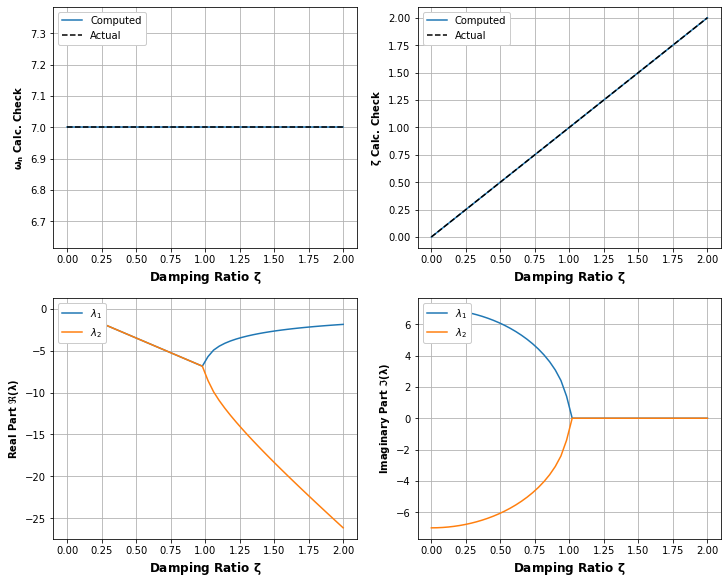

In [101]:


omega_n = 7.
zetas = np.complex128(np.linspace(0., 2.))
zetas_real = np.real(zetas)  # For plotting to avoid messages

lambda_1 = -zetas*omega_n + omega_n*np.sqrt(zetas**2 - 1.)
lambda_2 = -zetas*omega_n - omega_n*np.sqrt(zetas**2 - 1.)


fig, ax_dict = plt.subplot_mosaic([['omega_check', 'zeta_check'],
                                   ['real_lambda', 'imag_lambda']],
                                  figsize = (10, 8),
                                  constrained_layout = True)


lambda_bar = (lambda_1 + lambda_2)/2
delta_lambda = lambda_1 - lambda_2
omega_check = np.sqrt(lambda_bar**2 - (delta_lambda/2)**2)
zeta_check = -lambda_bar/omega_check

ax_dict['omega_check'].plot(zetas_real, np.real(omega_check), label = 'Computed')
ax_dict['zeta_check'].plot(zetas_real, np.real(zeta_check), label = 'Computed')

ax_dict['omega_check'].plot(zetas_real, omega_n*np.ones(zetas.shape), 'k--', label = 'Actual')
ax_dict['zeta_check'].plot(zetas_real, zetas_real, 'k--', label = 'Actual')

ax_dict['real_lambda'].plot(zetas_real, np.real(lambda_1), label = '$\lambda_1$')
ax_dict['real_lambda'].plot(zetas_real, np.real(lambda_2), label = '$\lambda_2$')

ax_dict['imag_lambda'].plot(zetas_real, np.imag(lambda_1), label = '$\lambda_1$')
ax_dict['imag_lambda'].plot(zetas_real, np.imag(lambda_2), label = '$\lambda_2$')

for a in ax_dict.values():
    a.grid()
    a.set_xlabel('Damping Ratio $\mathbf{\zeta}$', fontweight = 'bold', fontsize = 12)

ax_dict['omega_check'].legend(framealpha = 1., loc = 'upper left')
ax_dict['zeta_check'].legend(framealpha = 1., loc = 'upper left')
ax_dict['real_lambda'].legend(framealpha = 1., loc = 'lower left')
ax_dict['imag_lambda'].legend(framealpha = 1., loc = 'upper right')

ax_dict['omega_check'].set_ylabel('$\mathbf{\omega_n}$ Calc. Check', fontweight = 'bold')
ax_dict['zeta_check'].set_ylabel('$\mathbf{\zeta}$ Calc. Check', fontweight = 'bold')
ax_dict['real_lambda'].set_ylabel('Real Part $\mathbf{\Re(\lambda)}$', fontweight = 'bold')
ax_dict['imag_lambda'].set_ylabel('Imaginary Part $\mathbf{\Im(\lambda)}$', fontweight = 'bold')



## Visual Representations of Eigenvalues and Eigenvectors

Even for the simple second order system above, there is a fair amount of visualization work that can be used to understand system behavior. These tools become critical as system complexity increases and the dynamics analysis drives design decisions or defines operating envelopes. Before finishing this section we'll cover the most common visual representations for understand eigenvalue and eigenvector characteristics -- note that visualization of the eigenvalues/poles are much more common than those of the eigenvectors, especially for high-order systems.

### Eigenvalue Visualisation: Root-Locus and Frequency-Damping Charts

For pure understanding of system dynamics, the "root locus" and "frequency-damping" charts offer invaluable insight. Other types of plots become more important for analysis or design of control systems and evaluating robustness or response to disturbances, but a first check on eigenvalue behavior is always worthwhile.

The **root-locus** plot displays the collected curve ("locus") of the characteristic equation roots (eigenvalues, or poles), often for various sweeps of parameters. In a control systems analysis, for example, one might sweep various gains to observe their impact on the closed-loop system dynamics. In this context we will stick to sweeps of the damping ratio for various natural frequencies, as with the plots above -- this will also help illustrate the key geometric features of the root locus plot. By plotting the real part of each eigenvalue on the X-axis and the complex part on the Y-axis:

- The distance from the origin is $\sqrt{n^2 + \omega^2} = \omega$, so systems with constant natural frequency lie along a circle centered at the origin
- The "underdamped" damping ratio is $\zeta = n/\omega_n$, ...




Text(0, 0.5, 'Damping Ratio $\\mathbf{\\zeta}$')

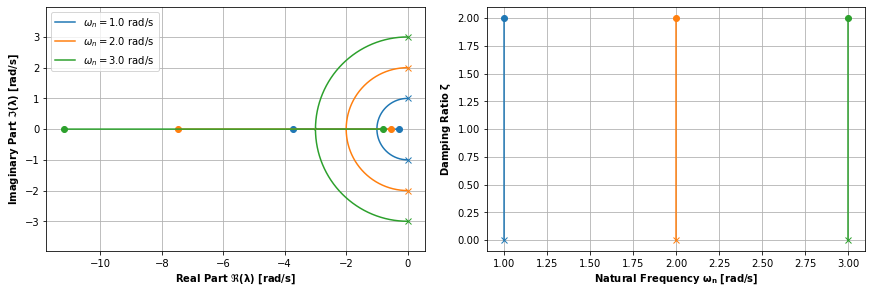

In [121]:
# Root-locus and frequency-damping plot examples


omega_ns = [1, 2, 3]
zetas = np.complex128(np.linspace(0., 2., 10000))
zetas_real = np.real(zetas)  # For plotting to avoid messages

fig, ax_dict = plt.subplot_mosaic([['root_locus', 'freq_damping']], 
                                 figsize = (12, 4), constrained_layout = True)

for ind, omega_n in enumerate(omega_ns):
    
    lambda_1 = -zetas*omega_n + omega_n*np.sqrt(zetas**2 - 1.)
    lambda_2 = -zetas*omega_n - omega_n*np.sqrt(zetas**2 - 1.)
    
    ax_dict['root_locus'].plot(np.real(lambda_1), np.imag(lambda_1), label = '$\omega_n = %.1f$ rad/s' % omega_n)
    ax_dict['root_locus'].plot(np.real(lambda_2), np.imag(lambda_2), color = 'C%i' % ind)
    
    ax_dict['freq_damping'].plot(omega_n*np.ones(zetas.shape), zetas_real, label = '$\omega_n = %.1f$ rad/s' % omega_n)
    
    for lambda_ind, marker in zip([0, -1], ['x', 'o']):
        ax_dict['root_locus'].plot(np.real(lambda_1)[lambda_ind], 
                                   np.imag(lambda_1)[lambda_ind], color = 'C%i' % ind, marker = marker)
        ax_dict['root_locus'].plot(np.real(lambda_2)[lambda_ind], 
                                   np.imag(lambda_2)[lambda_ind], color = 'C%i' % ind, marker = marker)
        
        ax_dict['freq_damping'].plot(omega_n*np.ones(zetas.shape)[lambda_ind], 
                                     zetas_real[lambda_ind], color = 'C%i' % ind, marker = marker)
    
    
ax_dict['root_locus'].grid()
ax_dict['root_locus'].axis('equal')
ax_dict['root_locus'].legend(loc = 'upper left')
ax_dict['root_locus'].set_xlabel('Real Part $\mathbf{\Re(\lambda)}$ [rad/s]', fontweight = 'bold')
ax_dict['root_locus'].set_ylabel('Imaginary Part $\mathbf{\Im(\lambda)}$ [rad/s]', fontweight = 'bold')

ax_dict['freq_damping'].grid()
ax_dict['freq_damping'].set_xlabel('Natural Frequency $\mathbf{\omega_n}$ [rad/s]', fontweight = 'bold')
ax_dict['freq_damping'].set_ylabel('Damping Ratio $\mathbf{\zeta}$', fontweight = 'bold')


### Eigenvector Representations

Visual representations of eigenvectors are much less common than those of the eigenvalues. For very simple systems, the modeshape  doesn't matter much, while for high-order systems with many degrees of freedom the representation requires a full-up animation of the system in question (one area where this **is** very common is in structural dynamics using the generalized eigenvalue formulation -- a topic for the future). Flight dynamics analyzes lie between these two extremes, with generally simple systems that have a handful of states but still exhibit complex behaviors, particularly in the lateral/directional partition. It's worthwhile, then, to have visualization tools available for our analysis. 
#### Vector Diagram
The first method is fairly straightforward and is what I will refer to as the **vector diagram** of each eigenvector. These are just the representations of each component of the eigenvector in the complex plane. This is a common representation; see, for example, Figure 6.1 of Etkin & Reid. It is customary to normalize a specific degree of freedom to unit value, since the scaling of the first-order eigenvalues is otherwise somewhat arbitrary. Vector diagrams for each eigenvector of the 2nd order system are shown below for various damping ratios.

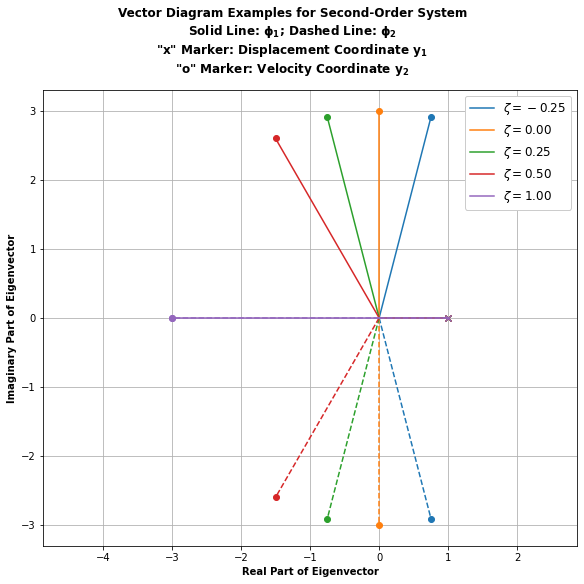

In [144]:
# Vector diagram representations of 2nd order eigenvectors

omega_n = 3.0
zetas = [-0.25, 0.0, 0.25, 0.5, 1.0]

fig, ax = plt.subplots(1, 1, figsize = (8, 8), constrained_layout = True)
for zind, zeta in enumerate(zetas):

    lambda_1 = -zeta*omega_n + 1j*omega_n*np.sqrt(np.complex128((1 - zeta**2)))
    lambda_2 = -zeta*omega_n - 1j*omega_n*np.sqrt(np.complex128((1 - zeta**2)))
    
    phi_1 = np.array([1, lambda_1])
    phi_2 = np.array([1, lambda_2])
    
    for mind, marker in enumerate(['x', 'o']):
        if not mind:
            label = '$\zeta = %.2f$' % zeta
        else:
            label = None
        ax.plot([0., np.real(phi_1[mind])],
                   [0., np.imag(phi_1[mind])],
                   color = 'C%i' % zind, label = label)
        ax.plot(np.real(phi_1[mind]), np.imag(phi_1[mind]),
                    color = 'C%i' % zind, marker = marker)
        
        ax.plot([0., np.real(phi_2[mind])],
                   [0., np.imag(phi_2[mind])],
                   color = 'C%i' % zind, linestyle = '--')
        ax.plot(np.real(phi_2[mind]), np.imag(phi_2[mind]),
                    color = 'C%i' % zind, marker = marker)
        
                             
ax.axis('equal')
ax.grid()
ax.set_xlabel('Real Part of Eigenvector', fontweight = 'bold')
ax.set_ylabel('Imaginary Part of Eigenvector', fontweight = 'bold')
ax.legend(framealpha = 1., fontsize = 12)
fig.suptitle('Vector Diagram Examples for Second-Order System\n'
            'Solid Line: $\mathbf{\phi_1}$; Dashed Line: $\mathbf{\phi_2}$\n'
            '"x" Marker: Displacement Coordinate $\mathbf{y_1}$\n"o" Marker: Velocity Coordinate $\mathbf{y_2}$',
            fontweight = 'bold');

The vector diagram displays the phasing relations between system states, with the overall vector magnitude growing or shrinking with respect to time as $t\cdot n$ and rotating in the complex plane according to $t\cdot \pm j\omega$. The positive root of $\omega$ will cause a counterclockwise rotation, while the negative root causes a clockwise rotation, which explains the apparent contradiction in phase angle between $\boldsymbol{\phi_1}$ and $\boldsymbol{\phi_2}$ -- in both cases, the velocity state leads the displacement state; the vectors simply rotate in different directions. The fully real eigenvalue for $\zeta = 1$ does not rotate since its eigenvalue lacks an imaginary component. 

#### "Equilibrium Diagrams"

The vector diagram is useful for understanding the phasing and relative magnitude of each state in a system. It does not inform us about the relative importance of those states in terms of their contribution to system dynamics -- high magnitude does not necessarily mean a state is a critical driver of a particular mode. For this purpose the "Equilibrium Diagram" can provide a better point of view. I have only seen this provided in McRuer/Graham/Ashkenas [Aircraft Dynamics & Automatic Control](https://apps.dtic.mil/sti/tr/pdf/AD0859330.pdf) in Figure 6-4 (page XXX of the PDF; a published book is also available). The authors refer to the plots as "time-vector" diagrams, and refer to the "vector diagram" above as "Phasors." While the "Phasor" terminology does bring back fond memories of undergraduate circuits, I am not a Star Trek fan and will dispense with it, and rename McRuer's "time-vector" concept to "equilibrium diagrams," since they are premised on balancing out each force/moment row in the equation of motion. 

The key concept is to use the system eigenvectors to balance out a particular row of the equation of motion associated with a disturbance in the shape of a specific eigenvalue:

$$
\dot{\mathbf{x}} = \mathbf{A}\boldsymbol{\phi_i} = \lambda_i \boldsymbol{\phi_i}
$$

From the above, we can go row-by-row through each state in $\mathbf{x}$ to obtain a scalar equation:

$$
\dot{x}_k = \mathbf{A}_k \boldsymbol{\phi_i} = \lambda_i (\phi_i)_k
$$
$$
\Rightarrow \mathbf{A}_k \boldsymbol{\phi_i} - \lambda_i (\phi_i)_k = 0
$$

Since the equation above equals zero, the chain of individual dot product entries in $\mathbf{A}_k \boldsymbol{\phi_i}$, together with the associated state rate of change $\dot{x}_k = \lambda_i (\phi_i)_k$, must form a closed shape that begins and ends at the origin. The relative size of each side of this resulting polygon tells us the importance of a state's contribution to the overall motion. Examples are given below for our second order system. Note that only equations associated with forces or moments are relevant -- kinematic relations such as $\dot{y}_1 = y_2$ do not provide useful information and are ommitted. 


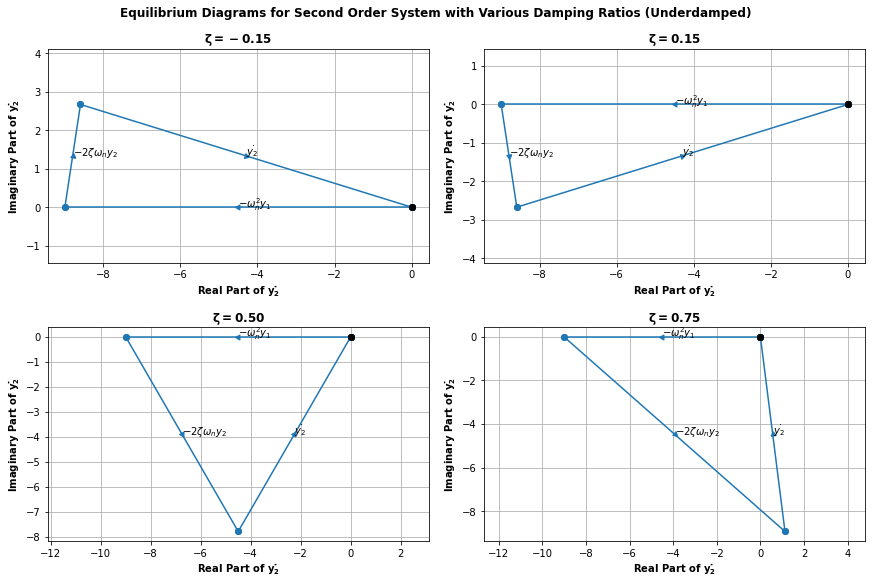

In [204]:
# Equilibrium diagrams for the second order system

omega_n = 3.0
zetas = [-0.15, 0.15, 0.5, 0.75]

fig, axes = plt.subplots(2, 2, figsize = (12, 8), constrained_layout = True)

point_labels = ['$-\omega_n^2 y_1$','$-2\zeta\omega_n y_2$', '$\dot{y_2}$']
for zind, (zeta, ax) in enumerate(zip(zetas, axes.flatten())):

    lambda_1 = -zeta*omega_n + 1j*omega_n*np.sqrt(np.complex128((1 - zeta**2)))
    lambda_2 = -zeta*omega_n - 1j*omega_n*np.sqrt(np.complex128((1 - zeta**2)))
    
    phi_1 = np.array([1, lambda_1])
    phi_2 = np.array([1, lambda_2])

    A = np.array([[0., 1.], [-omega_n**2, -2*zeta*omega_n]])
    
    for k in [1, ]:
        
        # Lambda 1/Phi 1
        A_row = A[k, :] * phi_1
        xdot = lambda_1 * phi_1[k]
        current_point = 0. + 1j*0.
        for ind, entry in enumerate([*A_row, -xdot]):
            if not ind: 
                label = '$\zeta = %.2f$' % zeta
            else:
                label = None
            next_point = current_point + entry
            ax.plot([np.real(current_point), np.real(next_point)], 
                    [np.imag(current_point), np.imag(next_point)],
                    label = label, color = 'C0', marker = 'o')
            ax.plot(0, 0, 'o', color = 'k')
            
            # Put an arrow and some text at the midpoint of the line
            midpoint = (next_point + current_point)/2
            angle = np.arctan2(np.imag(next_point - current_point), np.real(next_point - current_point))
            ax.plot(np.real(midpoint), np.imag(midpoint), marker = (3, 0, angle*180/np.pi - 90),
                   color = 'C0')
            
            ax.text(np.real(midpoint), np.imag(midpoint), point_labels[ind])
            current_point = next_point
            
        
    ax.grid()
    ax.axis('equal')
    ax.set_title('$\mathbf{\zeta = %.2f}$' % zeta)
    ax.set_xlabel('Real Part of $\mathbf{\dot{y_2}}$', fontweight = 'bold');
    ax.set_ylabel('Imaginary Part of $\mathbf{\dot{y_2}}$', fontweight = 'bold');
    
fig.suptitle('Equilibrium Diagrams for Second Order System with Various Damping Ratios (Underdamped)',
            fontweight = 'bold');

For the second order system, these plots are simply another way to visiualize the basic relation:

$$
\dot{y}_2 = -\omega_n^2 y_1 - 2\zeta\omega_n^2 y_2
$$

Although the direction of each eigenvector component is embedded in these plots, the terms in each matrix row can reverse them for negative entries. The major insight this diagram provides is an understanding of which system states (and corresponding matrix entries) dominate the behavior of a particular eigenvector. 